### Basic New Keynesian (NK) Model Using the Sequence-Space Jacobian (SSJ) Library in Python

This notebook replicates the NK model presented in Celso José Costa Junior's Understanding DSGE Models, using the equations in levels rather than their log-linearized form. The SSJ library works directly with equations in levels and automatically linearizes them around the steady state.

### The model

#### Households:

Households maximize a standard CRRA utility function subject to a budget constraint:

\begin{equation}
    \max_{C_t,L_t, K_{t+1}} \mathbf{E} \sum_{t=0}^{\infty} \beta^t \left( \frac{C_t^{1-\sigma}}{1-\sigma} - \frac{L_t^{1+\phi}}{1+\phi} \right)
\end{equation}

subject to: $P_t(C_t+I_t) = W_tL_t + R_tK_t + \Pi_t$

Where:
- $C_t$: Consumption of goods at time t.
- $L_t$: Number of hours worked at time t.
- $K_t$: Physical capital stock available at the beginning of period t.
- $I_t$: Level of investment at time t.
- $W_t$: Level of wages at time t.
- $R_t$: Return on capital at time t.
- $P_t$: General price level at time t.
- $\Pi_t$: Retail firms' profits, distributed to households at time t.
- $\beta$: Intertemporal discount factor (measuring the degree of patience).
- $\sigma$: Coefficient of relative risk aversion (inverse of the intertemporal elasticity of substitution).
- $\phi$: Marginal disutility in respect of labor supply (inverse of the Frisch elasticity of labor supply).

Also, capital accumulates according to $K_{t+1} = (1-\delta)K_t + I_t$ , where:
- $\delta$: Depreciation rate of physical capital.



#### Firms:

The rigidity of price in the model comes from the monopolistic structure of the market. The economy’s producing sector is thus divided into two parts: intermediate goods sector and final goods sector. The first part consists of large number of firms (whole-sale firms) that produces intermediate goods $Y_{j}$: each firm produces a different type of intermediate good that contain a certain degree of substituibility, i.e. there is a $\psi>0$ that represents a elasticity of substitution. The rigidity of price affects those firms directly. The second part consists of a firm (retail firms) that agregates the intermediate goods to one final good.


Algebricaly talking, the functional form for aggregation technology is:

\begin{equation}
    Y_t = \left( \int_{0}^{1} Y_{j,t}^{\frac{\psi-1}{\psi}} dj \right)^{\frac{\psi}{\psi -1}}    
\end{equation}


- $Y_t$: The product of retailers at time t.
- $\psi$: Elasticity of substitution between wholesale goods


The intermediate firms solve the problem of minimizing costs of production or simply maximizing profit:

\begin{equation}
    \max_{L_{j,t}, K_{j,t}, P{j,t}} \Pi_{j,t} = Y_{j,t} P_{j,t}- W_t L_{j,t} - R_t K_{j,t} 
\end{equation}



The production function is given by $Y_{j,t} = A_t K_{j,t}^{\alpha} L_{j,t}^{1-\alpha}$. Once the intermediate goods are imperfect substitutes there is going to be a friction: a markup. However, when $\psi \rightarrow \infty$ the price $P_{j,t}$ is going to be exactly the marginal cost $MC_t$ (the whole algebra is developed in the book cited).

Meanwhile, the representative retail firm solves the problem below:


\begin{equation}
    \max_{Y_{j,t}} \Pi_t = P_t Y_t - \int_{0}^{1}P_{j,t}Y_{j,t}dj = P_t \left( \int_{0}^{1}Y_{j,t}^{\frac{\psi-1}{\psi}} dj \right)^\frac{\psi-1}{\psi} - P_{j,t} \int_{0}^{1} Y_{j,t} dj
\end{equation}



#### Equilibrium:

\begin{equation}
    Y_t=C_t+I_t
\end{equation}

### Equations derivated after dealing with first order conditions:

\begin{equation}
    C_t^\sigma L_t^\phi = \frac{W_t}{P_t}
\end{equation}

\begin{equation}
    \left[\frac{\mathbb{E}(C_{t+1})}{C_t} \right]^\sigma = \beta \left[ (1-\delta) + \mathbb{E} \left(\frac{R_{t+1}}{P_{t+1}} \right)\right]
\end{equation}

\begin{equation}
    K_{t+1}=(1-\delta)K_t+I_t
\end{equation}

\begin{equation}
    Y_t = A_t K_t^{\alpha} L_t^{1-\alpha}
\end{equation}

\begin{equation}
    K_t = \alpha \frac{Y_t}{R_t} MC_t
\end{equation}

\begin{equation}
    L_t = (1-\alpha) \frac{Y_t}{W_t} MC_t
\end{equation}


\begin{equation}
    P_t^{*} \left( \frac{\psi}{\psi-1} \right) \mathbb{E} \sum_{i=0}^{\infty}(\beta \theta)^{i}MC_{t+i}
\end{equation}


\begin{equation}
    P_t = \left[ \theta P_{t-1}^{1-\psi} + (1-\theta) P_t^{* 1-\psi}     \right]^{\frac{1}{1-\psi}}
\end{equation}


\begin{equation}
    \pi_t = \frac{P}{P_{t-1}}
\end{equation}


\begin{equation}
    Y_t = C_t + I_t
\end{equation}

In [ ]:
# Use this package only if you want to visualize the DAG of he project 
!pip install graphviz

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sequence_jacobian import simple, create_model

In [2]:
from sequence_jacobian import drawdag # Import only if you want to visualize the DAG of the project 

In [3]:
@simple
def calvo(pi, beta, theta, psi):
    x  = ((1 - theta*pi**(psi-1))/(1 - theta))**(1/(1-psi)) 
    Gp = x*(psi-1)/psi                                      
    MC = Gp - beta*theta*pi(+1)*Gp(+1)                        
    return x, Gp, MC

@simple
def firm(K, L, A, MC, alpha):
    Y  = A * K(-1)**alpha * L**(1-alpha)      
    R = alpha   * MC * Y / K(-1)            
    W  = (1-alpha)* MC * Y / L               
    return Y, R, W

@simple
def capital(K, delta):
    I = K - (1-delta)*K(-1)                  
    return I

@simple
def monetary(C, pi, beta, sigma):
    i = 1/(beta*(C(+1)/C)**(-sigma)/pi(+1)) - 1
    return i

@simple
def equilibrium(C, L, W, R, Y, I, pi, i, beta, sigma, delta, phi, phi_pi):
    labor  = C**sigma * L**phi - W                                 
    euler  = (C(+1)/C)**sigma - beta*((1-delta) + R(+1))           
    goods  = Y - C - I                                       
    taylor = i - ((1/beta - 1) + phi_pi*(pi - 1))                   
    return labor, euler, goods, taylor

In [4]:
NK = create_model([calvo, firm, capital, monetary, equilibrium], name="NK")

print(NK)
print(f"Blocks: {NK.blocks}")

<Model 'NK'>
Blocks: [<SimpleBlock 'monetary'>, <SimpleBlock 'capital'>, <SimpleBlock 'calvo'>, <SimpleBlock 'firm'>, <SimpleBlock 'equilibrium'>]


In [5]:
unknowns = ['C', 'K', 'L', 'pi']
targets  = ['labor', 'euler', 'goods', 'taylor']
inputs   = ['A']

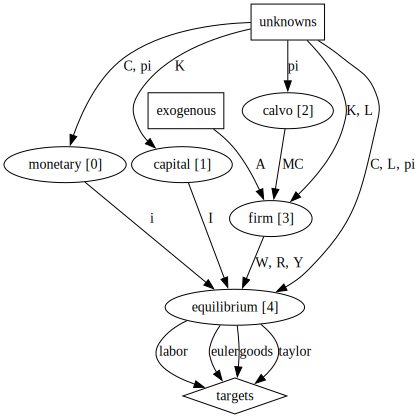

In [8]:
# DAG: it shows the dynamic of the solution given to the NK model.
drawdag(NK, inputs, unknowns, targets)

In [9]:
calibration = {"A": 1., "pi": 1., "sigma": 2.0, "phi": 1.5, "beta": 0.985,
               "delta": 0.025, "alpha": 0.35, "psi": 8., "theta": 0.75, "phi_pi": 1.5}
unknowns_ss = {"C": 0.739, "K": 1.547, "L": 0.537}
targets_ss  = {"labor": 0., "euler": 0., "goods": 0.}   # pi=1 fixo na calibracao

In [ ]:
ss = NK.solve_steady_state(calibration, unknowns_ss, targets_ss, solver="hybr")

for k in ["C", "K", "L", "Y", "I", "MC", "W", "R", "x", "pi", "i"]:
    print(f"  {k:>3s} = {ss[k]:.5f}")

    C = 0.73922
    K = 1.54712
    L = 0.53721
    Y = 0.77790
    I = 0.03868
   MC = 0.22859
    W = 0.21516
    R = 0.04023
    x = 1.00000
   pi = 1.00000
    i = 0.01523

  markup bruto = 4.375   (psi/(psi-1) = 1.143)


In [11]:
G = NK.solve_jacobian(ss, unknowns, targets, inputs, T=300)
print(G)

<JacobianDict outputs=['C', 'K', 'L', 'pi', 'x', 'Gp', 'MC', 'Y', 'R', 'W', 'I', 'i', 'labor', 'euler', 'goods', 'taylor'], inputs=['A']>


In [12]:
T, impact, rho = 300, 0.01, 0.95
dA = impact * rho**np.arange(T)            # IRF de um AR(1): 1, rho, rho^2, ...

In [13]:
varlist = [("A","Productivity","brown"), ("Y","Output","green"),
           ("C","Consumption","blue"), ("I","Investment","cyan"),
           ("L","Labor","red"), ("K","Capital","black"),
           ("W","Level of wages","purple"), ("R","Return on capital","orange"),
           ("MC","Marginal cost","grey"), ("pi","Inflation","magenta"),
           ("i","Nominal interest rate","teal")]

irf = {"A": 100 * dA / ss["A"]}               # o choque (input exogeno)
for v, _, _ in varlist:
    if v == "A":
        continue
    irf[v] = 100 * (G[v]["A"] @ dA) / ss[v]   # % de desvio do ss

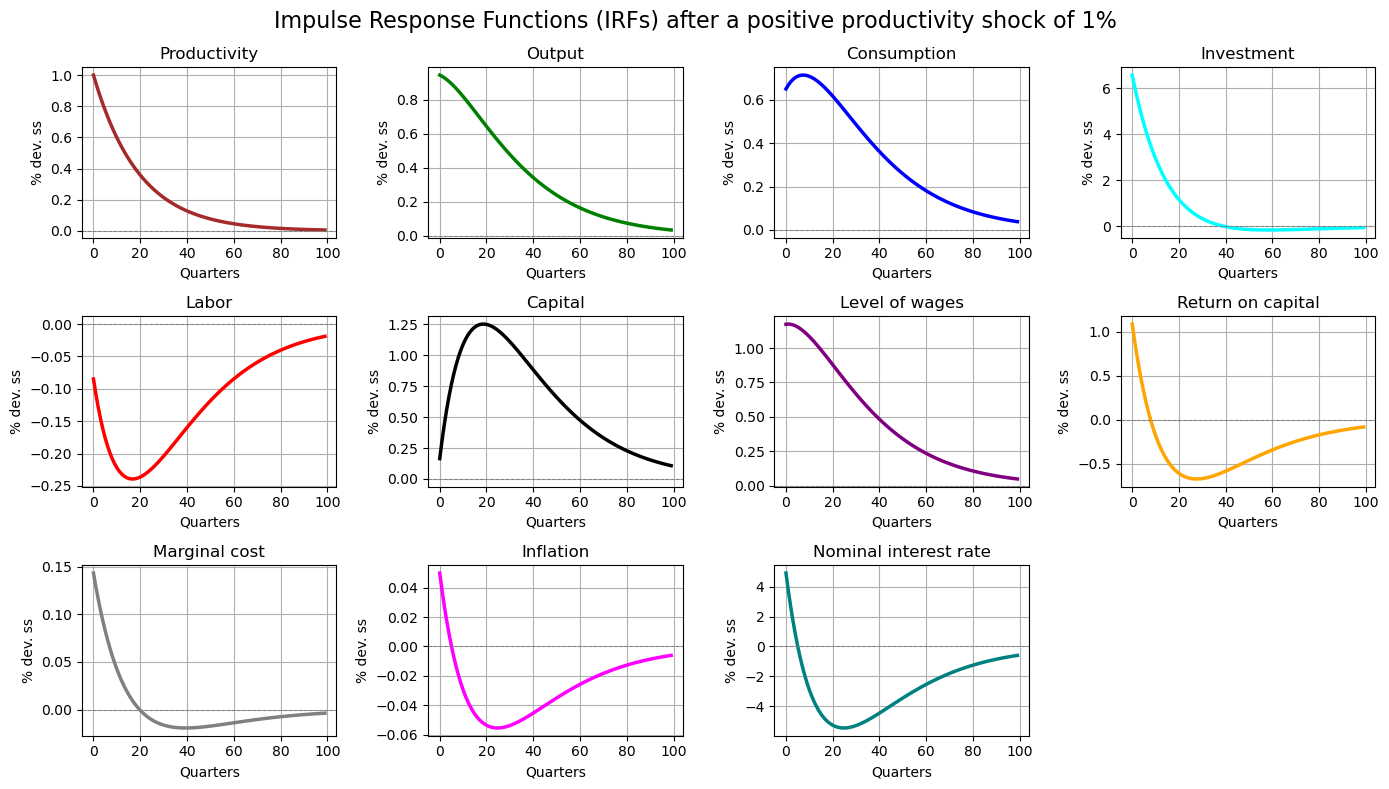

In [15]:
fig, axs = plt.subplots(3, 4, figsize=(14, 8))
for ax, (v, title, color) in zip(axs.flatten(), varlist):
    ax.plot(irf[v][:100], lw=2.5, color=color)
    ax.axhline(0, color="grey", lw=0.7, ls="--")
    ax.set_title(title); ax.set_xlabel("Quarters"); ax.set_ylabel("% dev. ss")
    ax.grid()
for ax in axs.flatten()[len(varlist):]:
    ax.axis("off")
fig.suptitle("Impulse Response Functions (IRFs) after a positive productivity shock of 1%", fontsize=16)
plt.tight_layout()
plt.show()